# CardioVision 3D - Step 1: Rigorous Dataset Audit
**Track A: Cardiovascular Risk Visualization & Prediction**

---
### Objective
Perform a rigorous data quality audit on the **UCI Extension of Z-Alizadeh Sani Dataset**.
This notebook strictly adheres to Step 1 requirements:
- No model training or evaluation
- No dataset modifications or imputations
- Conservative feature classification and leakage evaluation
- Full transparency into missingness, distributions, formatting, and modeling risks


## 1. Dataset Loading

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Add workspace src directory to path
sys.path.append(os.path.abspath(os.path.join('..', 'src')))
from dataset_audit import (
    locate_dataset, load_dataset, dataset_basic_info, build_data_dictionary,
    audit_missing_values, audit_duplicates, audit_targets, audit_target_leakage,
    audit_feature_types, audit_unique_values, audit_numerical_features,
    audit_data_quality, save_reports, KNOWN_TARGET_COLS, RANDOM_SEED
)

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
np.random.seed(RANDOM_SEED)

dataset_path, exists = locate_dataset()
if not exists:
    raise FileNotFoundError("REQUIRED DATASET MISSING! Please place 'extention of Z-Alizadeh sani dataset.xlsx' under data/")

df = load_dataset(dataset_path)
info = dataset_basic_info(df, dataset_path)

print(f"Dataset Path: {info['dataset_path']}")
print(f"Number of Rows: {info['num_rows']}")
print(f"Number of Columns: {info['num_cols']}")
print(f"Memory Footprint: {info['memory_usage_mb']} MB")


Dataset Path: C:\Users\Daksh\OneDrive\Desktop\ML 3D\data\extention of Z-Alizadeh sani dataset.xlsx
Number of Rows: 303
Number of Columns: 59
Memory Footprint: 0.1514 MB


In [2]:
print("Column Names:")
print(info['columns'])


Column Names:
['Age', 'Weight', 'Length', 'Sex', 'BMI', 'DM', 'HTN', 'Current Smoker', 'EX-Smoker', 'FH', 'Obesity', 'CRF', 'CVA', 'Airway disease', 'Thyroid Disease', 'CHF', 'DLP', 'BP', 'PR', 'Edema', 'Weak Peripheral Pulse', 'Lung rales', 'Systolic Murmur', 'Diastolic Murmur', 'Typical Chest Pain', 'Dyspnea', 'Function Class', 'Atypical', 'Nonanginal', 'Exertional CP', 'LowTH Ang', 'Q Wave', 'St Elevation', 'St Depression', 'Tinversion', 'LVH', 'Poor R Progression', 'BBB', 'FBS', 'CR', 'TG', 'LDL', 'HDL', 'BUN', 'ESR', 'HB', 'K', 'Na', 'WBC', 'Lymph', 'Neut', 'PLT', 'EF-TTE', 'Region RWMA', 'VHD', 'LAD', 'LCX', 'RCA', 'Cath']


In [3]:
df.head(5)

,Age,Weight,Length,Sex,BMI,DM,HTN,Current Smoker,EX-Smoker,FH,...,Lymph,Neut,PLT,EF-TTE,Region RWMA,VHD,LAD,LCX,RCA,Cath
0,53,90,175,Male,29.387755,0,1,1,0,0,...,39,52,261,50,0,N,Stenotic,Normal,Stenotic,CAD
1,67,70,157,Fmale,28.398718,0,1,0,0,0,...,38,55,165,40,4,N,Stenotic,Stenotic,Normal,CAD
2,54,54,164,Male,20.077335,0,0,1,0,0,...,38,60,230,40,2,mild,Stenotic,Normal,Normal,CAD
3,66,67,158,Fmale,26.838648,0,1,0,0,0,...,18,72,742,55,0,Severe,Normal,Normal,Normal,Normal
4,50,87,153,Fmale,37.165193,0,1,0,0,0,...,55,39,274,50,0,Severe,Normal,Normal,Normal,Normal


In [4]:
df.tail(5)

,Age,Weight,Length,Sex,BMI,DM,HTN,Current Smoker,EX-Smoker,FH,...,Lymph,Neut,PLT,EF-TTE,Region RWMA,VHD,LAD,LCX,RCA,Cath
298,58,84,168,Male,29.761905,0,0,0,0,0,...,34,58,251,45,0,N,Stenotic,Stenotic,Stenotic,CAD
299,55,64,152,Fmale,27.700831,0,0,0,0,0,...,16,80,377,40,0,mild,Normal,Normal,Normal,Normal
300,48,77,160,Fmale,30.078125,0,1,0,0,1,...,35,55,279,55,0,N,Normal,Normal,Normal,Normal
301,57,90,159,Fmale,35.599858,1,0,0,0,0,...,48,40,208,55,0,N,Normal,Normal,Normal,Normal
302,56,85,170,Fmale,29.411765,0,1,1,0,0,...,32,55,302,55,0,N,Stenotic,Normal,Normal,CAD


In [5]:
df.dtypes

Age                        int64
Weight                     int64
Length                     int64
Sex                          str
BMI                      float64
DM                         int64
HTN                        int64
Current Smoker             int64
EX-Smoker                  int64
FH                         int64
Obesity                      str
CRF                          str
CVA                          str
Airway disease               str
Thyroid Disease              str
CHF                          str
DLP                          str
BP                         int64
PR                         int64
Edema                      int64
Weak Peripheral Pulse        str
Lung rales                   str
Systolic Murmur              str
Diastolic Murmur             str
Typical Chest Pain         int64
Dyspnea                      str
Function Class             int64
Atypical                     str
Nonanginal                   str
Exertional CP                str
LowTH Ang 

## 2. Data Dictionary

In [6]:
data_dict_df = build_data_dictionary(df)
data_dict_df


,column_name,data_type,num_unique_values,missing_count,missing_percentage,suggested_type,example_values,medical_meaning
0,Age,int64,46,0,0.0,Numerical,"53, 67, 54",Meaning requires verification
1,Weight,int64,54,0,0.0,Numerical,"90, 70, 54",Meaning requires verification
2,Length,int64,44,0,0.0,Numerical,"175, 157, 164",Meaning requires verification
3,Sex,str,2,0,0.0,Categorical / Binary,"Male, Fmale",Meaning requires verification
4,BMI,float64,263,0,0.0,Numerical,"29.387755102040817, 28.398718000730252, 20.077...",Meaning requires verification
5,DM,int64,2,0,0.0,Categorical / Binary,"0, 1",Meaning requires verification
6,HTN,int64,2,0,0.0,Categorical / Binary,"1, 0",Meaning requires verification
7,Current Smoker,int64,2,0,0.0,Categorical / Binary,"1, 0",Meaning requires verification
8,EX-Smoker,int64,2,0,0.0,Categorical / Binary,"0, 1",Meaning requires verification
9,FH,int64,2,0,0.0,Categorical / Binary,"0, 1",Meaning requires verification


## 3. Missing Values Audit

In [7]:
missing_df = audit_missing_values(df)
print(f"Total columns with missing values: {(missing_df['missing_count'] > 0).sum()}")
missing_df


Total columns with missing values: 0


,column,missing_count,missing_percentage
0,Age,0,0.0
1,Weight,0,0.0
2,Length,0,0.0
3,Sex,0,0.0
4,BMI,0,0.0
5,DM,0,0.0
6,HTN,0,0.0
7,Current Smoker,0,0.0
8,EX-Smoker,0,0.0
9,FH,0,0.0


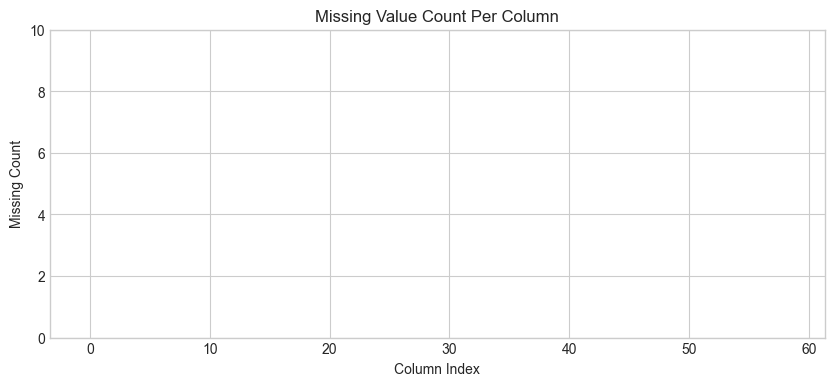

In [8]:
plt.figure(figsize=(10, 4))
plt.bar(range(len(df.columns)), df.isnull().sum(), color='navy')
plt.title("Missing Value Count Per Column")
plt.xlabel("Column Index")
plt.ylabel("Missing Count")
plt.ylim(0, 10)
plt.show()


## 4. Duplicates Audit

In [9]:
dup_audit = audit_duplicates(df)
print(f"Total Rows: {dup_audit['num_rows']}")
print(f"Exact Duplicate Rows: {dup_audit['exact_duplicate_rows']} ({dup_audit['exact_duplicate_percentage']}%)")
print("Duplicate checks on potential identifier columns:", dup_audit['id_column_duplicates'])


Total Rows: 303
Exact Duplicate Rows: 0 (0.0%)
Duplicate checks on potential identifier columns: {'Thyroid Disease': np.int64(301), 'Nonanginal': np.int64(301)}


## 5. Target Audit

In [10]:
target_audit_res = audit_targets(df)
for target_name, details in target_audit_res.items():
    print(f"=== TARGET: {target_name} ===")
    if details.get('present'):
        print(f"Unique Values: {details['unique_values']}")
        print(f"Class Counts: {details['class_counts']}")
        print(f"Class Percentages: {details['class_percentages']}")
        print(f"Missing Count: {details['missing_count']}")
    else:
        print(details['note'])
    print()


=== TARGET: LAD ===
Unique Values: ['Stenotic', 'Normal']
Class Counts: {'Stenotic': 177, 'Normal': 126}
Class Percentages: {'Stenotic': 58.42, 'Normal': 41.58}
Missing Count: 0

=== TARGET: LCX ===
Unique Values: ['Normal', 'Stenotic']
Class Counts: {'Normal': 184, 'Stenotic': 119}
Class Percentages: {'Normal': 60.73, 'Stenotic': 39.27}
Missing Count: 0

=== TARGET: RCA ===
Unique Values: ['Stenotic', 'Normal']
Class Counts: {'Normal': 189, 'Stenotic': 114}
Class Percentages: {'Normal': 62.38, 'Stenotic': 37.62}
Missing Count: 0

=== TARGET: Cath ===
Unique Values: ['CAD', 'Normal']
Class Counts: {'CAD': 216, 'Normal': 87}
Class Percentages: {'CAD': 71.29, 'Normal': 28.71}
Missing Count: 0

=== TARGET: CAD ===
Target column not found with exact name in dataset



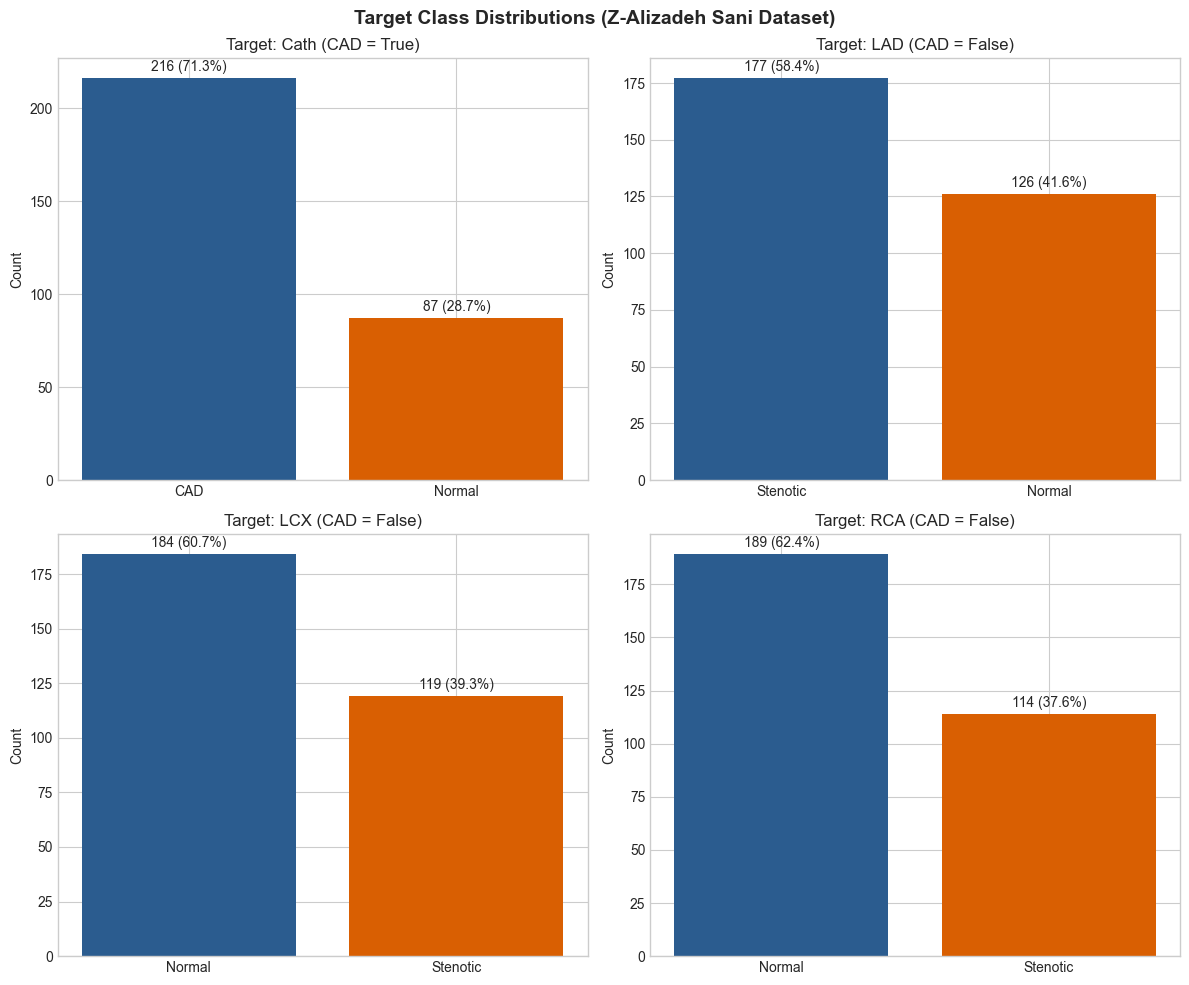

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("Target Class Distributions (Z-Alizadeh Sani Dataset)", fontsize=14, fontweight='bold')

targets_to_plot = ['Cath', 'LAD', 'LCX', 'RCA']
for ax, target_name in zip(axes.flatten(), targets_to_plot):
    if target_name in df.columns:
        counts = df[target_name].value_counts()
        bars = ax.bar(counts.index.astype(str), counts.values, color=['#2b5c8f', '#d95f02'])
        ax.set_title(f"Target: {target_name} (CAD = {target_name == 'Cath'})")
        ax.set_ylabel("Count")
        for bar in bars:
            height = bar.get_height()
            ax.annotate(f"{height} ({height/len(df)*100:.1f}%)",
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3), textcoords="offset points",
                        ha='center', va='bottom')

plt.tight_layout()
plt.show()


## 6. Target Leakage Audit

In [12]:
leakage_df = audit_target_leakage(df)
leakage_df


,Column,Potential_Role,Reason,Recommendation
0,Age,Candidate Feature,Clinical/demographic baseline feature,Keep
1,Weight,Candidate Feature,Clinical/demographic baseline feature,Keep
2,Length,Candidate Feature,Clinical/demographic baseline feature,Keep
3,Sex,Candidate Feature,Clinical/demographic baseline feature,Keep
4,BMI,Candidate Feature,Clinical/demographic baseline feature,Keep
5,DM,Candidate Feature,Clinical/demographic baseline feature,Keep
6,HTN,Candidate Feature,Clinical/demographic baseline feature,Keep
7,Current Smoker,Candidate Feature,Clinical/demographic baseline feature,Keep
8,EX-Smoker,Candidate Feature,Clinical/demographic baseline feature,Keep
9,FH,Candidate Feature,Clinical/demographic baseline feature,Keep


## 7. Feature Type Audit

In [13]:
feature_types = audit_feature_types(df)
for ftype, col_list in feature_types.items():
    print(f"=== {ftype.upper()} ({len(col_list)}) ===")
    print(col_list)
    print()


=== NUMERICAL (21) ===
['Age', 'Weight', 'Length', 'BMI', 'BP', 'PR', 'FBS', 'CR', 'TG', 'LDL', 'HDL', 'BUN', 'ESR', 'HB', 'K', 'Na', 'WBC', 'Lymph', 'Neut', 'PLT', 'EF-TTE']

=== BINARY (29) ===
['Sex', 'DM', 'HTN', 'Current Smoker', 'EX-Smoker', 'FH', 'Obesity', 'CRF', 'CVA', 'Airway disease', 'Thyroid Disease', 'CHF', 'DLP', 'Edema', 'Weak Peripheral Pulse', 'Lung rales', 'Systolic Murmur', 'Diastolic Murmur', 'Typical Chest Pain', 'Dyspnea', 'Atypical', 'Nonanginal', 'LowTH Ang', 'Q Wave', 'St Elevation', 'St Depression', 'Tinversion', 'LVH', 'Poor R Progression']

=== CATEGORICAL (5) ===
['Function Class', 'Exertional CP', 'BBB', 'Region RWMA', 'VHD']

=== ORDINAL (0) ===
[]

=== TEXT (0) ===
[]

=== TARGET (4) ===
['LAD', 'LCX', 'RCA', 'Cath']

=== POSSIBLE_LEAKAGE (0) ===
[]

=== UNKNOWN (0) ===
[]



## 8. Unique Value Audit

In [14]:
unique_val_df = audit_unique_values(df)
print(f"Total Categorical/Binary Unique Value Rows Audited: {len(unique_val_df)}")
rare_or_issue = unique_val_df[(unique_val_df['formatting_issue_flag']) | (unique_val_df['percentage'] < 5.0)]
rare_or_issue.head(20)


Total Categorical/Binary Unique Value Rows Audited: 202


,feature,value,frequency,percentage,formatting_issue_flag
9,EX-Smoker,1,10,3.30,False
15,CRF,Y,6,1.98,False
17,CVA,Y,5,1.65,False
19,Airway disease,Y,11,3.63,False
21,Thyroid Disease,Y,7,2.31,False
23,CHF,Y,1,0.33,False
33,BP,180,7,2.31,False
34,BP,90,4,1.32,False
35,BP,170,4,1.32,False
36,BP,135,4,1.32,False


## 9. Numerical Feature Audit

In [15]:
num_audit_df = audit_numerical_features(df)
num_audit_df


,feature,count,mean,median,std,min,q1,q3,max,iqr,outlier_count,outlier_percentage,lower_bound,upper_bound
0,Age,303,58.8977,58.0000,10.3923,30.0000,51.0000,66.0000,86.0000,15.0000,0,0.00,28.5000,88.5000
1,Weight,303,73.8317,74.0000,11.9874,48.0000,65.0000,81.0000,120.0000,16.0000,3,0.99,41.0000,105.0000
2,Length,303,164.7162,165.0000,9.3277,140.0000,158.0000,171.0000,188.0000,13.0000,0,0.00,138.5000,190.5000
3,BMI,303,27.2483,26.7755,4.0989,18.1154,24.5144,29.4118,40.9007,4.8974,6,1.98,17.1683,36.7578
4,BP,303,129.5545,130.0000,18.9381,90.0000,120.0000,140.0000,190.0000,20.0000,9,2.97,90.0000,170.0000
5,PR,303,75.1419,70.0000,8.9118,50.0000,70.0000,80.0000,110.0000,10.0000,13,4.29,55.0000,95.0000
6,FBS,303,119.1848,98.0000,52.0797,62.0000,88.5000,130.0000,400.0000,41.5000,30,9.90,26.2500,192.2500
7,CR,303,1.0556,1.0000,0.2643,0.5000,0.9000,1.2000,2.2000,0.3000,8,2.64,0.4500,1.6500
8,TG,303,150.3432,122.0000,97.9595,37.0000,90.0000,177.0000,1050.0000,87.0000,16,5.28,-40.5000,307.5000
9,LDL,303,104.6436,100.0000,35.3967,18.0000,80.0000,122.0000,232.0000,42.0000,6,1.98,17.0000,185.0000


## 10. Data Quality Checks

In [16]:
dq_results = audit_data_quality(df)
print("Constant Columns (1 unique value):", dq_results['constant_columns'])
print("Near-Constant Columns (>= 95% single value):", dq_results['near_constant_columns'])
print("Whitespace Issue Columns:", dq_results['whitespace_issue_columns'])
print("Columns with Zero Values:", dq_results['zero_value_counts'])
print("Columns with Negative Values:", dq_results['negative_value_counts'])


Constant Columns (1 unique value): ['Exertional CP']
Near-Constant Columns (>= 95% single value): [('EX-Smoker', np.float64(96.7)), ('CRF', np.float64(98.02)), ('CVA', np.float64(98.35)), ('Airway disease', np.float64(96.37)), ('Thyroid Disease', np.float64(97.69)), ('CHF', np.float64(99.67)), ('Edema', np.float64(96.04)), ('Weak Peripheral Pulse', np.float64(98.35)), ('Lung rales', np.float64(96.37)), ('Diastolic Murmur', np.float64(97.03)), ('LowTH Ang', np.float64(99.34)), ('St Elevation', np.float64(95.38)), ('Poor R Progression', np.float64(97.03))]
Whitespace Issue Columns: []
Columns with Zero Values: {'DM': np.int64(213), 'HTN': np.int64(124), 'Current Smoker': np.int64(240), 'EX-Smoker': np.int64(293), 'FH': np.int64(255), 'Edema': np.int64(291), 'Typical Chest Pain': np.int64(139), 'Function Class': np.int64(211), 'Q Wave': np.int64(287), 'St Elevation': np.int64(289), 'St Depression': np.int64(232), 'Tinversion': np.int64(213), 'Region RWMA': np.int64(217)}
Columns with Nega

## 11. Correlation & Association Exploration

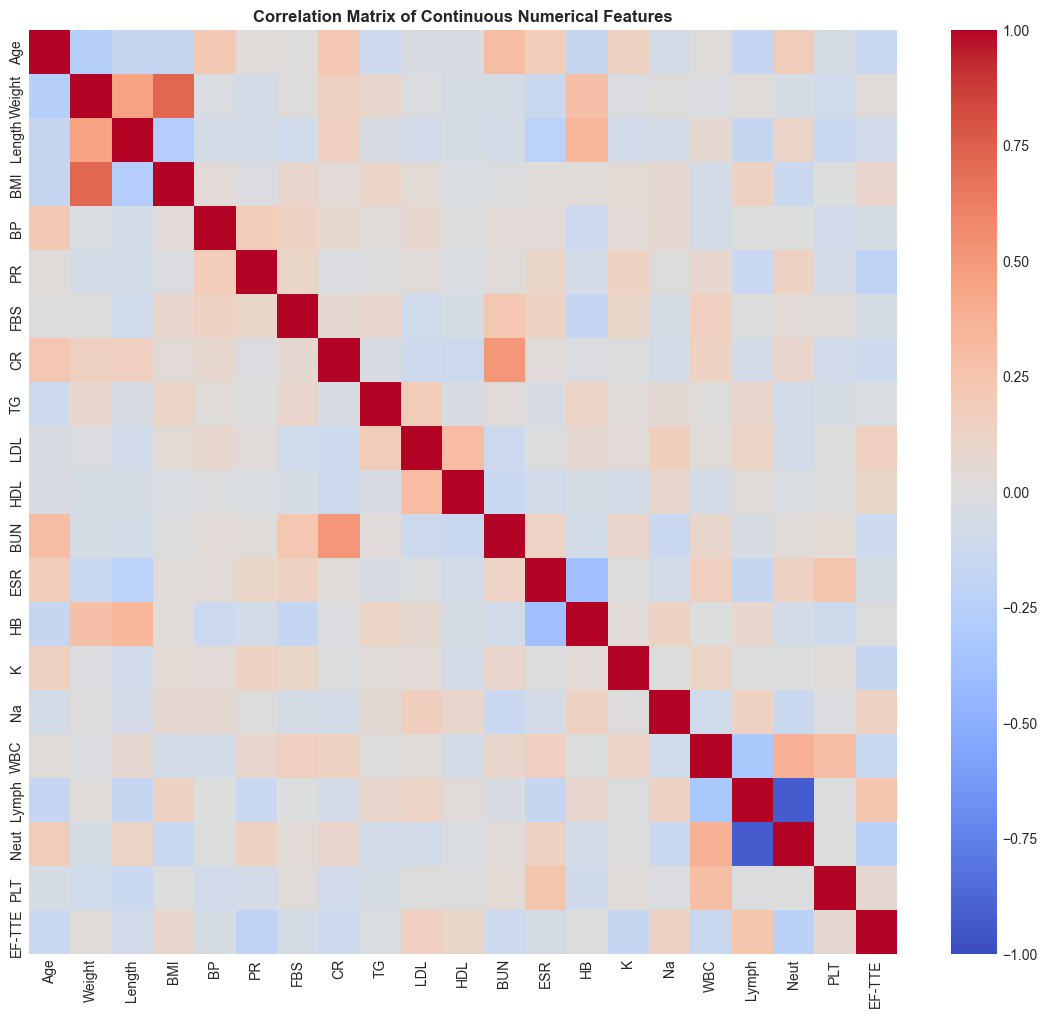

In [17]:
num_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c]) and df[c].nunique() > 10]
corr_matrix = df[num_cols].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Matrix of Continuous Numerical Features", fontsize=12, fontweight='bold')
plt.show()


## 12. Dataset Size and Modeling Risk Analysis

### Key Observations & Risks:
1. **Sample Size vs Feature Dimensionality ($N=303$, $P=54$)**:
   - High risk of overfitting if unregularized complex models are evaluated without strict cross-validation.
   - Requires robust Stratified K-Fold CV (5-fold or 10-fold) with fixed random seeds.

2. **Target Class Distribution**:
   - **Cath (CAD Overall)**: 71.3% CAD vs 28.7% Normal (Imbalanced).
   - **LAD Stenosis**: 58.4% Stenotic vs 41.6% Normal.
   - **LCX Stenosis**: 39.3% Stenotic vs 60.7% Normal.
   - **RCA Stenosis**: 37.6% Stenotic vs 62.4% Normal.
   - Standard Accuracy will be misleading; ROC-AUC, PR-AUC, F1-score, Sensitivity, and Specificity are required.

3. **Near-Constant / Low-Variance Features**:
   - `Exertional CP` has 0 variance (100% 'N').
   - 13 features have >=95% single value (e.g. `CHF` 99.67% 'N', `LowTH Ang` 99.34% 'N').
   - High risk of tree splits wasting depth on zero-information features.

4. **Formatting Inconsistencies**:
   - `Sex` column encodes females as `'Fmale'` (typo in raw dataset). Must be mapped cleanly during pre-processing in Step 2.


## 13. Data Audit Report Generation

In [18]:
print("=== CARDIOVISION 3D - STEP 1 DATA AUDIT REPORT ===")
print(f"DATASET: Rows={df.shape[0]}, Columns={df.shape[1]}")
print(f"TARGETS: Cath(CAD={df['Cath'].value_counts().get('CAD',0)}), LAD(Stenotic={df['LAD'].value_counts().get('Stenotic',0)}), LCX(Stenotic={df['LCX'].value_counts().get('Stenotic',0)}), RCA(Stenotic={df['RCA'].value_counts().get('Stenotic',0)})")
print(f"QUALITY: Missing={df.isnull().sum().sum()}, Exact Duplicates={df.duplicated().sum()}, Constant Cols={dq_results['constant_columns']}")
print(f"FEATURES: Numerical={len(feature_types['numerical'])}, Binary={len(feature_types['binary'])}, Categorical={len(feature_types['categorical'])}")
print(f"LEAKAGE: Excluded Targets = {feature_types['target']}")


=== CARDIOVISION 3D - STEP 1 DATA AUDIT REPORT ===
DATASET: Rows=303, Columns=59
TARGETS: Cath(CAD=216), LAD(Stenotic=177), LCX(Stenotic=119), RCA(Stenotic=114)
QUALITY: Missing=0, Exact Duplicates=0, Constant Cols=['Exertional CP']
FEATURES: Numerical=21, Binary=29, Categorical=5
LEAKAGE: Excluded Targets = ['LAD', 'LCX', 'RCA', 'Cath']


## 14. Save Audit Outputs

In [19]:
reports_to_save = {
    'dataset_summary': pd.DataFrame([info]),
    'feature_dictionary': data_dict_df,
    'missing_values': missing_df,
    'target_distribution': pd.DataFrame(target_audit_res),
    'leakage_audit': leakage_df,
    'numerical_features_audit': num_audit_df,
    'unique_values_audit': unique_val_df
}

saved_report_paths = save_reports(reports_to_save, output_dir='../reports')
print("Saved Reports:")
for p in saved_report_paths:
    print(f" - {p}")


Saved Reports:
 - ../reports\dataset_summary.csv
 - ../reports\feature_dictionary.csv
 - ../reports\missing_values.csv
 - ../reports\target_distribution.csv
 - ../reports\leakage_audit.csv
 - ../reports\numerical_features_audit.csv
 - ../reports\unique_values_audit.csv
